##### 2. to project monthly EOF onto daily GH anomalies

In [2]:
import numpy as np
import xarray as xr

In [11]:
import glob

In [14]:
from pathlib import Path

cwd = Path.cwd()
era5_dir = cwd.parents[6]

# build a path relative to two-up:
gh_dir = era5_dir / 'shared_data/Datasets/ERA5/plev'

- open monthly EOF for the corresponding month

In [512]:
month = 12
ilev = 10 # hPa

In [513]:
original_eoff = f"/net/cfc/s2s/rachwu/scripts/sh_ssw_impact/aparc_project/SouthernWarmings_module/data/zeof/ERA5.EOF1.z{ilev}.Mon{month:02d}.nc"

In [514]:
original_eof = xr.open_dataset(original_eoff)['eof1']

In [515]:
monthly_eoff = f"/net/cfc/s2s/rachwu/scripts/sh_ssw_impact/aparc_project/SouthernWarmings_module/src/sh_ssw_methods/zeof/ERA5.EOF1.z{ilev}.Mon{month:02d}.nc"

In [516]:
monthly_eof = xr.open_dataset(monthly_eoff)['eof1']

In [517]:
monthly_eof

<xarray.DataArray 'eof1' (lat: 36, lon: 180)> Size: 26kB
[6480 values with dtype=float32]
Coordinates:
    mode     int64 8B ...
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0

In [518]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

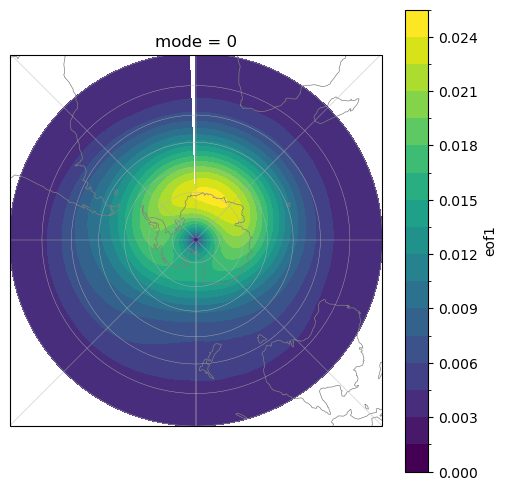

In [519]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = monthly_eof.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

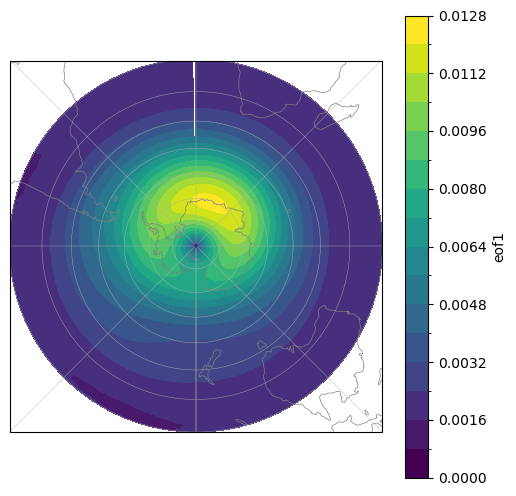

In [520]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = original_eof.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

- for single file

In [551]:
gh_file = 'processed/era5_geopot_10hPa_1979_2023.nc'

In [572]:
gh_era5 = xr.open_dataset(gh_file)
gh_era5 = gh_era5['var129']

In [573]:
da = gh_era5

In [554]:
lv = 1000
out_dir = './processed/'

In [574]:
da

<xarray.DataArray 'var129' (time: 16436, plev: 1, lat: 46, lon: 180)> Size: 544MB
[136090080 values with dtype=float32]
Coordinates:
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat      (lat) float64 368B 0.0 -2.0 -4.0 -6.0 ... -84.0 -86.0 -88.0 -90.0
  * time     (time) datetime64[ns] 131kB 1979-01-01 1979-01-02 ... 2023-12-31
  * plev     (plev) int64 8B 1000
Attributes:
    table:    128

In [566]:
def compute_daily_clim(
    ds: xr.Dataset | xr.DataArray,
    mon: int,
    *,
    drop_feb29: bool = False,
    lat_slice: tuple[float, float] = (-90, -20),
    ilev: int | None = None,
    varname: str = "var129",
    save_file: bool = False,
    out_dir: str | Path = "./processed",
) -> xr.DataArray:
    """
    Compute daily (day-of-month) climatology for a given month
    from an already loaded multi-year geopotential dataset.

    Parameters
    ----------
    ds : xr.Dataset or xr.DataArray
        Multi-year geopotential height dataset or dataarray.
    mon : int
        Calendar month (1–12).
    drop_feb29 : bool, optional
        Whether to drop Feb 29 (default False).
    lat_slice : tuple, optional
        Latitude range (default: (-90, -20)).
    ilev : int or None, optional
        Pressure level in hPa or Pa (used for subsetting and filename).
    varname : str, optional
        Variable name to use if `ds` is a Dataset (default: 'var129').
    save_file : bool, optional
        Save the climatology to NetCDF (default False).
    out_dir : str or Path, optional
        Directory for output NetCDF (default './processed').

    Returns
    -------
    xr.DataArray
        Daily climatology for that month: (day, lat, lon)
    """

    # --- Select data variable ---
    if isinstance(ds, xr.Dataset):
        if varname not in ds:
            raise KeyError(f"Variable '{varname}' not found in dataset.")
        z = ds[varname]
    elif isinstance(ds, xr.DataArray):
        z = ds
    else:
        raise TypeError("Input must be an xarray Dataset or DataArray.")

    # Convert geopotential to meters if needed
    if "units" in z.attrs and "m**2 s**-2" in z.attrs["units"]:
        z = z / 9.81
    z.attrs["units"] = "m"

    # --- Sort and subset latitude before processing ---
    if "lat" not in z.coords:
        raise ValueError("Latitude coordinate 'lat' not found in dataset.")
    if not np.all(np.diff(z["lat"]) > 0):
        z = z.sortby("lat")
    z = z.sel(lat=slice(*lat_slice))

    # --- Handle level selection if present ---
    if ilev is not None and "plev" in z.dims:
        lev_val = ilev 
        if lev_val not in z["plev"]:
            raise ValueError(
                f"Requested level {lev_val} not found in dataset. Available: {z['plev'].values}"
            )
        z = z.sel(plev=lev_val)
        # Keep plev dimension explicitly
        z = z.expand_dims("plev") if "plev" not in z.dims else z
        z = z.assign_coords(plev=[lev_val])
        # Ensure consistent dimension order
        if set(["time", "plev", "lat", "lon"]).issubset(z.dims):
            z = z.transpose("time", "plev", "lat", "lon")

    z.attrs["level_hPa"] = ilev
    z = z.sortby("time")

    # --- Select month ---
    z_mon = z.where(z.time.dt.month == mon, drop=True)
    if z_mon.time.size == 0:
        raise ValueError(f"No data found for month {mon}.")

    # --- Handle leap year day ---
    if drop_feb29 and mon == 2:
        z_mon = z_mon.sel(time=~((z_mon.time.dt.month == 2) & (z_mon.time.dt.day == 29)))

    # --- Compute daily climatology across years ---
    clim = z_mon.groupby("time.day").mean("time")
    clim.name = "z_daily_clim"
    clim.attrs.update(
        dict(
            description=f"Daily climatology (DoM) for month={mon}, 1979–2023",
            units="m",
        )
    )

    # --- Optional save ---
    if save_file:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        start_year = pd.to_datetime(z.time.values[0]).year
        end_year = pd.to_datetime(z.time.values[-1]).year
        ilev_label = f"_{int(ilev)}hPa" if ilev is not None else ""
        out_path = out_dir / f"daily_clim_z{ilev_label}_Mon{mon:02d}_{start_year}_{end_year}_era5.nc"

        if not out_path.exists():
            clim.to_netcdf(out_path)
            print(f"Saved climatology to {out_path}")
        else:
            print(f"File already exists: {out_path}")

    return clim


In [630]:
def project_daily_pc1(
    monthly_eof: xr.DataArray,
    gh_data: xr.Dataset | xr.DataArray,
    *,
    month: int,
    lat_hi: float = -20,
    lat_lo: float = -90,
    varname: str = "var129",
    ilev: int | None = None,
) -> xr.DataArray:
    """
    Project daily geopotential height anomalies onto a monthly EOF pattern
    to obtain daily PC1 time series for a given level and month.

    Parameters
    ----------
    monthly_eof : xr.DataArray
        EOF1 spatial pattern (lat, lon) for a specific month and level.
    gh_data : xr.Dataset or xr.DataArray
        Multi-year geopotential height dataset containing 'time', 'lat', and 'lon'.
    gh_clim : xr.DataArray
        Daily climatology for that same month (day, lat, lon).
    month : int
        Calendar month (1–12) corresponding to the EOF pattern and climatology.
    lat_hi, lat_lo : float, optional
        Latitude limits for projection (default: -20 to -90).
    varname : str, optional
        Variable name if `gh_data` is a Dataset (default: 'var129').
    ilev : int or None, optional
        Level in hPa or Pa to select if multi-level data are provided.

    Returns
    -------
    xr.DataArray
        Daily standardized PC1 time series for that month (time,).
    """

    # --- Select variable ---
    if isinstance(gh_data, xr.Dataset):
        if varname not in gh_data:
            raise KeyError(f"Variable '{varname}' not found in dataset.")
        z = gh_data[varname]
    elif isinstance(gh_data, xr.DataArray):
        z = gh_data
    else:
        raise TypeError("gh_data must be an xarray Dataset or DataArray.")

    # --- Convert geopotential units to meters ---
    z = z / 9.81
    z.attrs["units"] = "m"

    # --- Select pressure level if available ---
    if ilev is not None and "plev" in z.dims:
        lev_val = ilev
        if lev_val not in z["plev"]:
            raise ValueError(
                f"Requested level {lev_val} not found. Available: {z['plev'].values}"
            )
        z = z.sel(plev=lev_val)

    # --- Sort latitude and restrict to region ---
    if not np.all(np.diff(z["lat"]) > 0):
        z = z.sortby("lat")
    z = z.sel(lat=slice(lat_lo, lat_hi))

    # --- Select only the target month ---
    z_mon = z.sel(time=z.time.dt.month == month)
    if z_mon.time.size == 0:
        raise ValueError(f"No data found for month {month} in provided dataset.")
        
    gh_clim = compute_daily_clim(z_mon,
            mon=month,
            ilev=ilev, # Pa
            varname=varname,
            drop_feb29=True,
            save_file=False)
        
    # --- Compute anomalies relative to given month’s climatology ---
    # Align day-of-month to climatology day coordinate
    gh_anom = z_mon.groupby("time.day") - gh_clim

    # --- Apply sqrt(cos(lat)) weighting ---
    w = np.sqrt(np.cos(np.deg2rad(gh_anom["lat"])))
    w2d = w.broadcast_like(monthly_eof)
    wgt_gh_anom = gh_anom * w2d

    # --- Project anomalies onto EOF pattern ---
    # pc(t) = ∑_lat ∑_lon [ wgt_gh_anom(t,lat,lon) * EOF1(lat,lon) ]
    pc1 = (wgt_gh_anom * monthly_eof).sum(dim=("lat", "lon"))

    return pc1


In [631]:
# --- Specify level and month ---
lv = 10   # hPa
mon = 6   # June

In [673]:
# --- File paths ---
base_dir = Path("./processed")
eof_file = base_dir / f"zeof_mj/ERA5.EOF1.z{lv}.Mon{mon:02d}.nc"
gh_file = base_dir / f"era5_geopot_{lv}hPa_1979_2023.nc"

In [675]:
# --- Load data ---
monthly_eof = xr.open_dataarray(eof_file)
gh_data = xr.open_dataset(gh_file)

In [676]:
pc1 = project_daily_pc1(
    monthly_eof=monthly_eof,
    gh_data=gh_data,
    month=mon,
    ilev=lv*100,
    lat_hi=-20,
    lat_lo=-90,
)

In [677]:
pc1

<xarray.DataArray (time: 1350)> Size: 11kB
array([-4.74168189e+07, -3.23526241e+07, -5.38966542e+07, ...,
        2.72592934e+08,  2.35914843e+08,  1.86786077e+08])
Coordinates:
  * time     (time) datetime64[ns] 11kB 1979-06-01 1979-06-02 ... 2023-06-30
    plev     (time) int64 11kB 1000 1000 1000 1000 1000 ... 1000 1000 1000 1000
    day      (time) int64 11kB 1 2 3 4 5 6 7 8 9 ... 22 23 24 25 26 27 28 29 30
    n        int64 8B ...

In [697]:
def compute_pc1_all_months(
    lv: int,
    *,
    base_dir: str | Path = "./processed",
    months: list[int] | None = None,
    lat_range: tuple[float, float] = (-90, -20),
    varname: str = "var129",
) -> dict[int, tuple[np.ndarray, np.ndarray]]:
    """
    Project daily geopotential height anomalies onto monthly EOF1 patterns
    for all years, returning (year, day) arrays for each month.

    Parameters
    ----------
    lv : int
        Pressure level in hPa (e.g., 10 for 10 hPa).
    base_dir : str or Path, optional
        Directory containing processed EOFs and geopotential data.
    months : list[int], optional
        List of months (default: [1..12]).
    lat_range : tuple, optional
        Latitude limits for projection (default: (-90, -20)).
    varname : str, optional
        Variable name in geopotential dataset (default: 'var129').

    Returns
    -------
    dict[int, tuple[np.ndarray, np.ndarray]]
        {month: (pc1_all, years)} where
        - pc1_all: ndarray (n_years, n_days)
        - years: array of corresponding year labels
    """

    base_dir = Path(base_dir)
    results = {}
    months = months or range(1, 13)

    # --- Load geopotential height dataset once ---
    gh_path = base_dir / f"era5_geopot_{lv}hPa_1979_2023.nc"
    if not gh_path.exists():
        raise FileNotFoundError(f"Missing geopotential file: {gh_path}")
    gh_data = xr.open_dataset(gh_path)

    # --- Loop through requested months ---
    for mon in months:
        print(f"\n=== Computing PC1 for z{lv}hPa Month {mon:02d} ===")

        eof_path = base_dir / f"zeof/ERA5.EOF1.z{lv}.Mon{mon:02d}.nc" #####
        if not eof_path.exists():
            print(f" Missing EOF file → {eof_path.name}, skipping month {mon:02d}")
            continue

        eof = xr.open_dataarray(eof_path)

        try:
            pc1 = project_daily_pc1(
                monthly_eof=eof,
                gh_data=gh_data,
                month=mon,
                ilev=lv*100,  # in Pa
                lat_hi=lat_range[1],
                lat_lo=lat_range[0],
                varname=varname,
            )
        except Exception as e:
            print(f" Failed to compute PC1 for month {mon:02d}: {e}")
            continue

        # --- Convert to (year, day) array ---
        grouped = list(pc1.groupby("time.year"))
        years = np.array([int(y) for y, _ in grouped])
        n_days = max(len(g) for _, g in grouped)
        pc1_all = np.full((len(years), n_days), np.nan)

        for i, (_, g) in enumerate(grouped):
            vals = g.values
            pc1_all[i, :len(vals)] = vals

        
        # standardise
        pc1_all_std = (pc1_all - np.mean(pc1_all, axis=0))/ np.std(pc1_all, axis=0)

        results[mon] = (pc1_all_std, years)

    
    print("\n Finished computing PC1 for all requested months.")
    return results


In [698]:
# Step 1: Compute PC1 arrays for all months
pc1_all_std = compute_pc1_all_months(
    lv=10,
    base_dir="./processed",
    months=range(6, 13),  # June–December
)


=== Computing PC1 for z10hPa Month 06 ===

=== Computing PC1 for z10hPa Month 07 ===

=== Computing PC1 for z10hPa Month 08 ===

=== Computing PC1 for z10hPa Month 09 ===

=== Computing PC1 for z10hPa Month 10 ===

=== Computing PC1 for z10hPa Month 11 ===

=== Computing PC1 for z10hPa Month 12 ===

 Finished computing PC1 for all requested months.


In [699]:
pc1_all_std

{6: (array([[-0.20079499, -0.13629487, -0.22127888, ...,  0.31188366,
           0.72016342,  1.1345405 ],
         [ 1.85778144,  2.01224038,  2.26237732, ...,  0.65686882,
           0.36820029,  0.31976057],
         [ 0.97912151,  1.11189259,  1.07097279, ...,  0.34312103,
           0.31118617,  0.15581016],
         ...,
         [ 0.10265346,  0.23291373,  0.20343872, ..., -0.42870245,
          -0.44267738, -0.43864192],
         [ 0.33919072,  0.23502069,  0.1069935 , ..., -0.31730017,
          -0.4902875 , -0.69172966],
         [-0.44949928, -0.86093076, -1.11633155, ...,  0.8400999 ,
           0.69376593,  0.54587471]]),
  array([1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989,
         1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
         2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
         2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
         2023])),
 7: (array([[ 1.20365751,  0.98862946, 

In [700]:
def write_daily_pc1(pc1_std_all, years, mon, lv, out_dir="."):
    """
    Write standardized daily PC1 for each year to text files like:
    daily.pc1.z10.197906.txt

    Parameters
    ----------
    pc1_std_all : (year, day) array-like
        Standardized PC1 values for a given month (e.g., shape (45, 30))
    years : list or array of int
        Year labels corresponding to axis 0
    mon : int
        Month number (1–12)
    lv : int
        Pressure level (e.g., 10 for 10 hPa)
    out_dir : str or Path
        Directory to save text files
    """
    pc1_std_all = np.asarray(pc1_std_all)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for i, yr in enumerate(years):
        vals = pc1_std_all[i, :]
        # format: year + 30 space-padded floats (width=9, precision=3)

        base = Path(out_dir)
        zeof_dir = base / "zeof"
        zeof_dir.mkdir(parents=True, exist_ok=True)

        line = f"{yr}" + "".join([f"{v:9.3f}" for v in vals])
        fname = zeof_dir / f"daily.pc1.z{lv}.{yr}{mon:02d}.txt"
        with open(fname, "w") as f:
            f.write(line + "\n")

In [701]:
def save_pc1_ascii_all_months(pc1_dict, lv: int, *, out_dir: str | Path = "./processed"):
    """
    Save standardized daily PC1 values for each month to ASCII files.

    Parameters
    ----------
    pc1_dict : dict[int, tuple[np.ndarray, np.ndarray]]
        Output from `compute_pc1_all_months`.
        Keys are months; values are (pc1_all, years).
    lv : int
        Pressure level in hPa (e.g., 10).
    out_dir : str or Path, optional
        Output base directory (default: './processed').
    """

    out_dir = Path(out_dir)
    for mon, (pc1_all, years) in pc1_dict.items():
        print(f"\n--- Writing standardized PC1 files for Month {mon:02d} ---")
        write_daily_pc1(pc1_all, years, mon, lv, out_dir=out_dir)
    print("\n All PC1 text files written successfully.")

In [702]:
# Step 2: Write to ASCII text files
save_pc1_ascii_all_months(pc1_all_std, lv=10, out_dir="./processed")


--- Writing standardized PC1 files for Month 06 ---

--- Writing standardized PC1 files for Month 07 ---

--- Writing standardized PC1 files for Month 08 ---

--- Writing standardized PC1 files for Month 09 ---

--- Writing standardized PC1 files for Month 10 ---

--- Writing standardized PC1 files for Month 11 ---

--- Writing standardized PC1 files for Month 12 ---

 All PC1 text files written successfully.


In [684]:
def output_daily_pc1(ilev, months, base_dir):

    # Step 1: Compute PC1 arrays for all months
    pc1_all_std = compute_pc1_all_months(
        lv=ilev,
        base_dir=base_dir,
        months=months,  # June–December
    )
    
    # Step 2: Write to ASCII text files
    save_pc1_ascii_all_months(pc1_all_std, lv=ilev, out_dir=base_dir)


In [671]:
months = range(6,13)

In [672]:
output_daily_pc1(10, months, "./processed")


=== Computing PC1 for z10hPa Month 06 ===


KeyboardInterrupt: 

- compute clim for the corresponding month

In [521]:
lat_hi = -20
lat_lo = -90

In [522]:
def pre(ds): return ds[['var129']].sel(lat=slice(lat_hi, lat_lo)).sel(plev=ilev*100)

In [523]:
import xarray as xr
import pandas as pd
import numpy as np

def compute_daily_clim(mon: int, drop_feb29: bool = False) -> xr.DataArray:
    """
    Daily (day-of-month) climatology for month `mon` across 1979–2023.
    Returns: clim(day, lat, lon) where day = 1..Nd for that month.
    """
    gh_fpath = str(gh_dir / f"era5_an_geopot_reg2_6h_*{mon:02d}.nc")

    # Open monthly files lazily; `pre` can already subset lat/level etc.
    ds = xr.open_mfdataset(gh_fpath, preprocess=pre, combine="by_coords", chunks="auto")
    ds = ds.sel(time=slice("1979-01-01", "2023-12-31"))

    # Variable & units: ERA5 var129 = geopotential (m^2 s^-2) -> meters
    z6h = ds["var129"] / 9.81
    z6h.attrs["units"] = "m"

    # Keep only this month (robust even if files include other months)
    z6h = z6h.where(z6h.time.dt.month == mon, drop=True)

    # --- Daily means WITHOUT densifying the time index ---
    # Use groupby("time.date") so we only aggregate existing days.
    daily = z6h.groupby("time.date").mean("time")
    daily = daily.rename({"date": "time"})
    daily = daily.assign_coords(time=pd.to_datetime(daily["time"].values))  # make it a proper datetime index

    # Optional: handle Feb 29 (only relevant when mon==2)
    if drop_feb29 and mon == 2:
        daily = daily.sel(time=~((daily.time.dt.month == 2) & (daily.time.dt.day == 29)))

    # --- Day-of-month climatology across years ---
    # Mean of all 1sts, all 2nds, ..., for this month
    clim = daily.groupby("time.day").mean("time")   # -> (day, lat, lon)
    clim.name = "z_daily_clim"
    clim.attrs.update(dict(description=f"Daily climatology (DoM) for month={mon}, 1979–2023", units="m"))

    return clim


In [524]:
gh_clim = compute_daily_clim(month).astype("float32").load()

In [525]:
gh_clim

<xarray.DataArray 'z_daily_clim' (day: 31, lat: 36, lon: 180)> Size: 804kB
array([[[30957.236, 30957.545, 30957.768, ..., 30956.45 , 30956.85 ,
         30957.045],
        [30966.92 , 30967.533, 30967.855, ..., 30965.652, 30966.164,
         30966.494],
        [30976.84 , 30977.46 , 30977.875, ..., 30975.277, 30975.953,
         30976.4  ],
        ...,
        [31341.691, 31341.605, 31341.566, ..., 31342.252, 31342.018,
         31341.828],
        [31358.21 , 31358.16 , 31358.133, ..., 31358.506, 31358.38 ,
         31358.281],
        [31374.66 , 31374.66 , 31374.66 , ..., 31374.66 , 31374.66 ,
         31374.66 ]],

       [[30956.45 , 30956.156, 30956.25 , ..., 30955.18 , 30955.71 ,
         30956.1  ],
        [30966.94 , 30967.033, 30966.94 , ..., 30965.277, 30965.93 ,
         30966.545],
        [30977.828, 30978.408, 30978.45 , ..., 30975.783, 30976.52 ,
         30977.256],
...
        [31901.594, 31901.594, 31901.598, ..., 31901.686, 31901.643,
         31901.617],
        [31907.695, 31907.678, 31907.67 , ..., 31907.775, 31907.742,
         31907.717],
        [31911.934, 31911.934, 31911.934, ..., 31911.934, 31911.934,
         31911.934]],

       [[30923.406, 30922.92 , 30922.316, ..., 30922.81 , 30923.3  ,
         30923.217],
        [30947.2  , 30946.762, 30946.498, ..., 30946.123, 30946.59 ,
         30946.973],
        [30971.877, 30971.855, 30972.117, ..., 30971.258, 30971.52 ,
         30971.836],
        ...,
        [31904.44 , 31904.408, 31904.387, ..., 31904.586, 31904.533,
         31904.48 ],
        [31911.127, 31911.098, 31911.072, ..., 31911.244, 31911.2  ,
         31911.156],
        [31915.916, 31915.916, 31915.916, ..., 31915.916, 31915.916,
         31915.916]]], dtype=float32)
Coordinates:
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    plev     float64 8B 1e+03
  * day      (day) int64 248B 1 2 3 4 5 6 7 8 9 ... 23 24 25 26 27 28 29 30 31
Attributes:
    units:        m
    description:  Daily climatology (DoM) for month=12, 1979–2023

- open single file for a given year to compute anom

In [526]:
def compute_anom(ghfile, clim, lat_hi, lat_lo):
    gh_single = xr.open_dataset(ghfile)

    gh_single = gh_single['var129'].resample(time="1D").mean()
    gh_single = gh_single.sel(plev=target_pa, lat=slice(lat_hi, lat_lo))/9.81

    gh_anom = gh_single - clim.values
    return gh_anom

In [527]:
gh_fpath = str(gh_dir / f"era5_an_geopot_reg2_6h_*{month:02d}.nc")

In [528]:
gh_fpath

'/net/cfc/s2s/shared_data/Datasets/ERA5/plev/era5_an_geopot_reg2_6h_*12.nc'

In [529]:
gh_files = sorted(glob.glob(gh_fpath))

In [530]:
gh_files = [f for f in gh_files if int(f.split('_')[-1][:4]) >= 1979]

In [531]:
(wgt_gh_anom* monthly_eof).sum(dim=("lat","lon"))

<xarray.DataArray (time: 30)> Size: 240B
array([ 2019.64930095,  1340.28768557,   825.88980204,   399.0310053 ,
           7.463453  ,   152.26011282,   221.55469241,   154.44710557,
         401.17058478,   288.79303681,   313.42694157,   242.90123932,
         136.77828573,  -165.09734674,  -442.00580077,  -713.89690617,
        -963.33189846, -1624.38852733, -1512.93984915, -1018.53517164,
        -796.72158222,  -999.55594857, -1957.72942982, -2452.06703782,
       -2578.72512994, -2591.1232337 , -4332.11381597, -3229.04736779,
       -1659.09769303,   -56.60255353])
Coordinates:
    plev     float64 8B 1e+03
  * time     (time) datetime64[ns] 240B 1979-06-01 1979-06-02 ... 1979-06-30
    mode     int64 8B 0

In [532]:
def project_daily_pc1(monthly_eof, gh_file, gh_clim, lat_hi, lat_lo):
    
    # compute gh anom
    gh_anom = compute_anom(gh_file, gh_clim, lat_hi, lat_lo)

    # weighted to match eof
    w = xr.apply_ufunc(np.cos, np.deg2rad(gh_anom["lat"])) ** 0.5
    w2d = w.broadcast_like(monthly_eof)

    wgt_gh_anom = gh_anom*w2d

    # project onto monthly eof
    pc1 = wgt_gh_anom* monthly_eof

    return pc1

- loop over all files

In [533]:
pc1 = []

for ighfile in gh_files:
    print(ighfile)
    ipc1 = project_daily_pc1(monthly_eof, ighfile, gh_clim, lat_hi, lat_lo)
    pc1.append(ipc1.sum(dim=("lat", "lon")))

/net/cfc/s2s/shared_data/Datasets/ERA5/plev/era5_an_geopot_reg2_6h_197912.nc
/net/cfc/s2s/shared_data/Datasets/ERA5/plev/era5_an_geopot_reg2_6h_198012.nc
/net/cfc/s2s/shared_data/Datasets/ERA5/plev/era5_an_geopot_reg2_6h_198112.nc
/net/cfc/s2s/shared_data/Datasets/ERA5/plev/era5_an_geopot_reg2_6h_198212.nc
/net/cfc/s2s/shared_data/Datasets/ERA5/plev/era5_an_geopot_reg2_6h_198312.nc
/net/cfc/s2s/shared_data/Datasets/ERA5/plev/era5_an_geopot_reg2_6h_198412.nc
/net/cfc/s2s/shared_data/Datasets/ERA5/plev/era5_an_geopot_reg2_6h_198512.nc
/net/cfc/s2s/shared_data/Datasets/ERA5/plev/era5_an_geopot_reg2_6h_198612.nc
/net/cfc/s2s/shared_data/Datasets/ERA5/plev/era5_an_geopot_reg2_6h_198712.nc
/net/cfc/s2s/shared_data/Datasets/ERA5/plev/era5_an_geopot_reg2_6h_198812.nc
/net/cfc/s2s/shared_data/Datasets/ERA5/plev/era5_an_geopot_reg2_6h_198912.nc
/net/cfc/s2s/shared_data/Datasets/ERA5/plev/era5_an_geopot_reg2_6h_199012.nc
/net/cfc/s2s/shared_data/Datasets/ERA5/plev/era5_an_geopot_reg2_6h_199112.nc

standardise

In [534]:
pc1_all  = [ipc1.values for ipc1 in pc1]

In [535]:
pc1_all = np.array(pc1_all)

In [536]:
pc1_all.shape

(45, 31)

In [537]:
pc1_all.shape

(45, 31)

In [538]:
pc1_std_all

array([[ 0.9861528 ,  1.03295175,  1.03778863, ...,  1.06779271,
         1.06005052,  1.07026816],
       [-0.47647947, -0.45499322, -0.45416712, ...,  1.83295541,
         1.83396065,  1.80971707],
       [-0.85299578, -0.77121974, -0.70839156, ...,  0.75877696,
         0.76333851,  0.78226535],
       ...,
       [-1.77907699, -1.78706055, -1.79393014, ..., -1.21037918,
        -1.30037402, -1.32695877],
       [-1.7602451 , -1.7136435 , -1.73017932, ..., -0.8421533 ,
        -0.72330624, -0.67251666],
       [-0.28578714, -0.28819245, -0.31087373, ..., -1.45193065,
        -1.5062041 , -1.54148031]])

In [539]:
# pc1_all has shape (n_years, n_days)
pc1_mean = np.nanmean(pc1_all, axis=0, keepdims=True)
pc1_std  = np.nanstd(pc1_all, axis=0, keepdims=True)

# standardized PC1
pc1_std_all = (pc1_all - pc1_mean) / pc1_std

In [540]:
pc1_std_all[0]

array([1.33877752, 1.39632378, 1.42354811, 1.46041446, 1.49794894,
       1.50420738, 1.49617239, 1.45893247, 1.47392176, 1.48908752,
       1.53810154, 1.61119144, 1.68661269, 1.75005152, 1.75397448,
       1.76588378, 1.80433583, 1.81680535, 1.81246621, 1.77975051,
       1.74722792, 1.70323461, 1.7134806 , 1.71820972, 1.697337  ,
       1.7129535 , 1.76262722, 1.81339764, 1.75108322, 1.67320821,
       1.65558398])

In [541]:
years = np.arange(1979,2023+1,1)

In [542]:
years

array([1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989,
       1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023])

In [543]:
def write_daily_pc1(pc1_std_all, years, mon, lv, out_dir="."):
    """
    Write standardized daily PC1 for each year to text files like:
    daily.pc1.z10.197906.txt

    Parameters
    ----------
    pc1_std_all : (year, day) array-like
        Standardized PC1 values for a given month (e.g., shape (45, 30))
    years : list or array of int
        Year labels corresponding to axis 0
    mon : int
        Month number (1–12)
    lv : int
        Pressure level (e.g., 10 for 10 hPa)
    out_dir : str or Path
        Directory to save text files
    """
    pc1_std_all = np.asarray(pc1_std_all)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for i, yr in enumerate(years):
        vals = pc1_std_all[i, :]
        # format: year + 30 space-padded floats (width=9, precision=3)

        base = Path(out_dir)
        zeof_dir = base / "zeof"
        zeof_dir.mkdir(parents=True, exist_ok=True)

        line = f"{yr}" + "".join([f"{v:9.3f}" for v in vals])
        fname = zeof_dir / f"daily.pc1.z{lv}.{yr}{mon:02d}.txt"
        with open(fname, "w") as f:
            f.write(line + "\n")

In [544]:
write_daily_pc1(pc1_std_all, years, month, ilev, out_dir=".")